# **TP2 - Bivariate Analysis**

<b>Exploratory Data Analysis & Unsuperivsed Learning </b><br>
**Course: PHAUK Sokkey, PhD** <br> 
**TP: HAS Sothea, PhD**

-------

**Objective**: To equip you all with the skills to analyze and interpret the relationship between two variables. You will explore these relationships as a function of time using the [`Gapminder`](https://pypi.org/project/gapminder/) dataset.

---------

> **The `Jupyter Notebook` for this TP can be downloaded here: [TP2-Bivariate-Gapminder](https://hassothea.github.io/EDA_ITC/TPs/TP2_Bivariate_Analysis.ipynb)**.

-------

In [47]:
import warnings
warnings.filterwarnings("ignore")
from gapminder import gapminder
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Correlation matrix

**a.** Compute correlation matrix of the three quantitative variables on year $1952$, $1987$ and then $2007$ using `pd.corr()`. Give a brief description of each correlation matrix.

In [48]:
df = gapminder

year1952 = df.query("year == 1952").drop(columns=["year"])
year1987 = df.query("year == 1987").drop(columns=["year"])
year2007 = df.query("year == 2007").drop(columns=["year"])

In [3]:
year1952.select_dtypes(include="number").corr().style.background_gradient()

,lifeExp,pop,gdpPercap
lifeExp,1.000000,-0.002725,0.278024
pop,-0.002725,1.000000,-0.025260
gdpPercap,0.278024,-0.025260,1.000000


In [4]:
year1987.select_dtypes(include="number").corr().style.background_gradient()

,lifeExp,pop,gdpPercap
lifeExp,1.000000,0.033062,0.749905
pop,0.033062,1.000000,-0.051705
gdpPercap,0.749905,-0.051705,1.000000


> Year 1987; GDP lowkey correlate with LifeExp => Richer = Healthier

In [5]:
year2007.select_dtypes(include="number").corr().style.background_gradient()

,lifeExp,pop,gdpPercap
lifeExp,1.000000,0.047553,0.678662
pop,0.047553,1.000000,-0.055676
gdpPercap,0.678662,-0.055676,1.000000


> Same conclusion as 1987

In [6]:
year1952[['gdpPercap', 'lifeExp']].corr(method='spearman')

,gdpPercap,lifeExp
gdpPercap,1.000000,0.768701
lifeExp,0.768701,1.000000


In [7]:
print(year1952.select_dtypes(include="number").corr(method="spearman"))
print("="*50)
print(year1987.select_dtypes(include="number").corr(method="spearman"))
print("="*50)
print(year2007.select_dtypes(include="number").corr(method="spearman"))

            lifeExp       pop  gdpPercap
lifeExp    1.000000  0.175466   0.768701
pop        0.175466  1.000000   0.086571
gdpPercap  0.768701  0.086571   1.000000
            lifeExp       pop  gdpPercap
lifeExp    1.000000  0.053419   0.892465
pop        0.053419  1.000000   0.008355
gdpPercap  0.892465  0.008355   1.000000
            lifeExp       pop  gdpPercap
lifeExp    1.000000  0.003355   0.856590
pop        0.003355  1.000000  -0.064588
gdpPercap  0.856590 -0.064588   1.000000


**c.** From the previous result, pick the most interesting pair of variables and plot a graphic illustrating their relationship for each year using proper axis scaling and title. Do you see one interesting country in 1952? Guess which country is it? Investigate why is this the case?

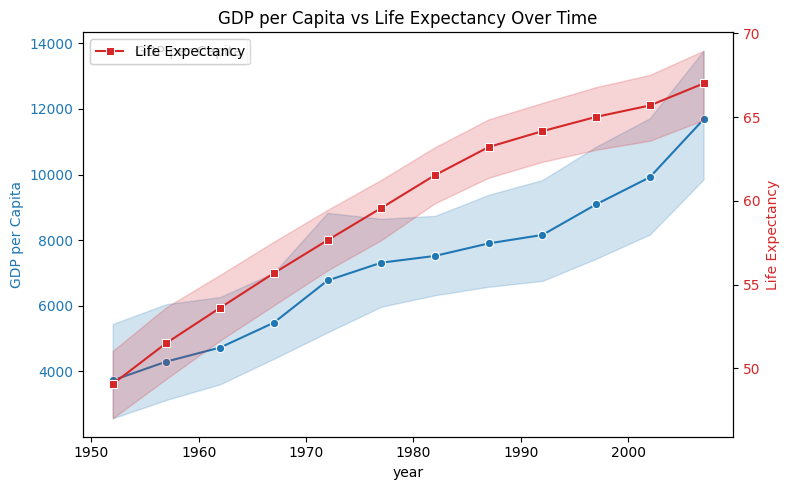

In [8]:
fig, ax1 = plt.subplots(figsize=(8,5))

sns.lineplot(data=df, x="year", y="gdpPercap", marker="o", ax=ax1, color='tab:blue', label='GDP per Capita')
ax1.set_ylabel("GDP per Capita", color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
sns.lineplot(data=df, x="year", y="lifeExp", marker="s", ax=ax2, color='tab:red', label='Life Expectancy')
ax2.set_ylabel("Life Expectancy", color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red') # range

plt.title("GDP per Capita vs Life Expectancy Over Time")
plt.tight_layout()
plt.show()

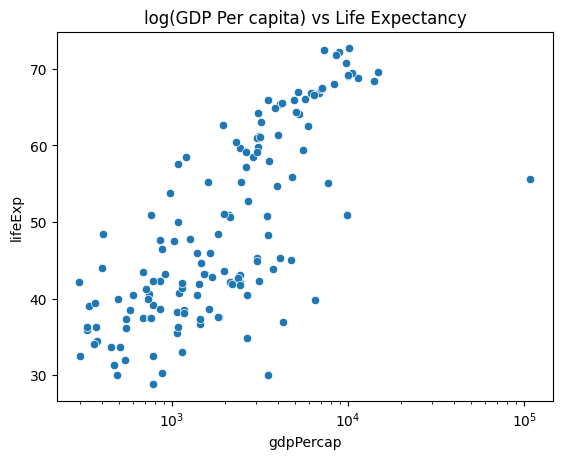

In [9]:
sns.scatterplot(data=year1952, x="gdpPercap", y="lifeExp")
plt.xscale("log")
plt.title("log(GDP Per capita) vs Life Expectancy")
plt.show()

**d.** Revisit your explanation of correlation matrix for year 1952 in question **a.**, can you see why we observed such a (poor) correlation in 1952!

> **Remark:** Correlation matrix can summarize linear relationship between pairs of quantitative variables but it might be inacurate and influenced by outliers, non-linearity, small sample size, confounding variables...

> There is an outlier in 1952 dataset.

# 2. Visualization with more information

`Scatterplot` is the primary graphic type for visualizing the relationship between two quantitative variables. Additionally, you can include other factors of interest using color, shape, size, facets, etc., depending on the type of those variables. 

------------

The following questions apply to the years 1952, 1987, and 2007:

**a.** Do you think health conditions and economies differ across continents? Visualize it in a graphic.

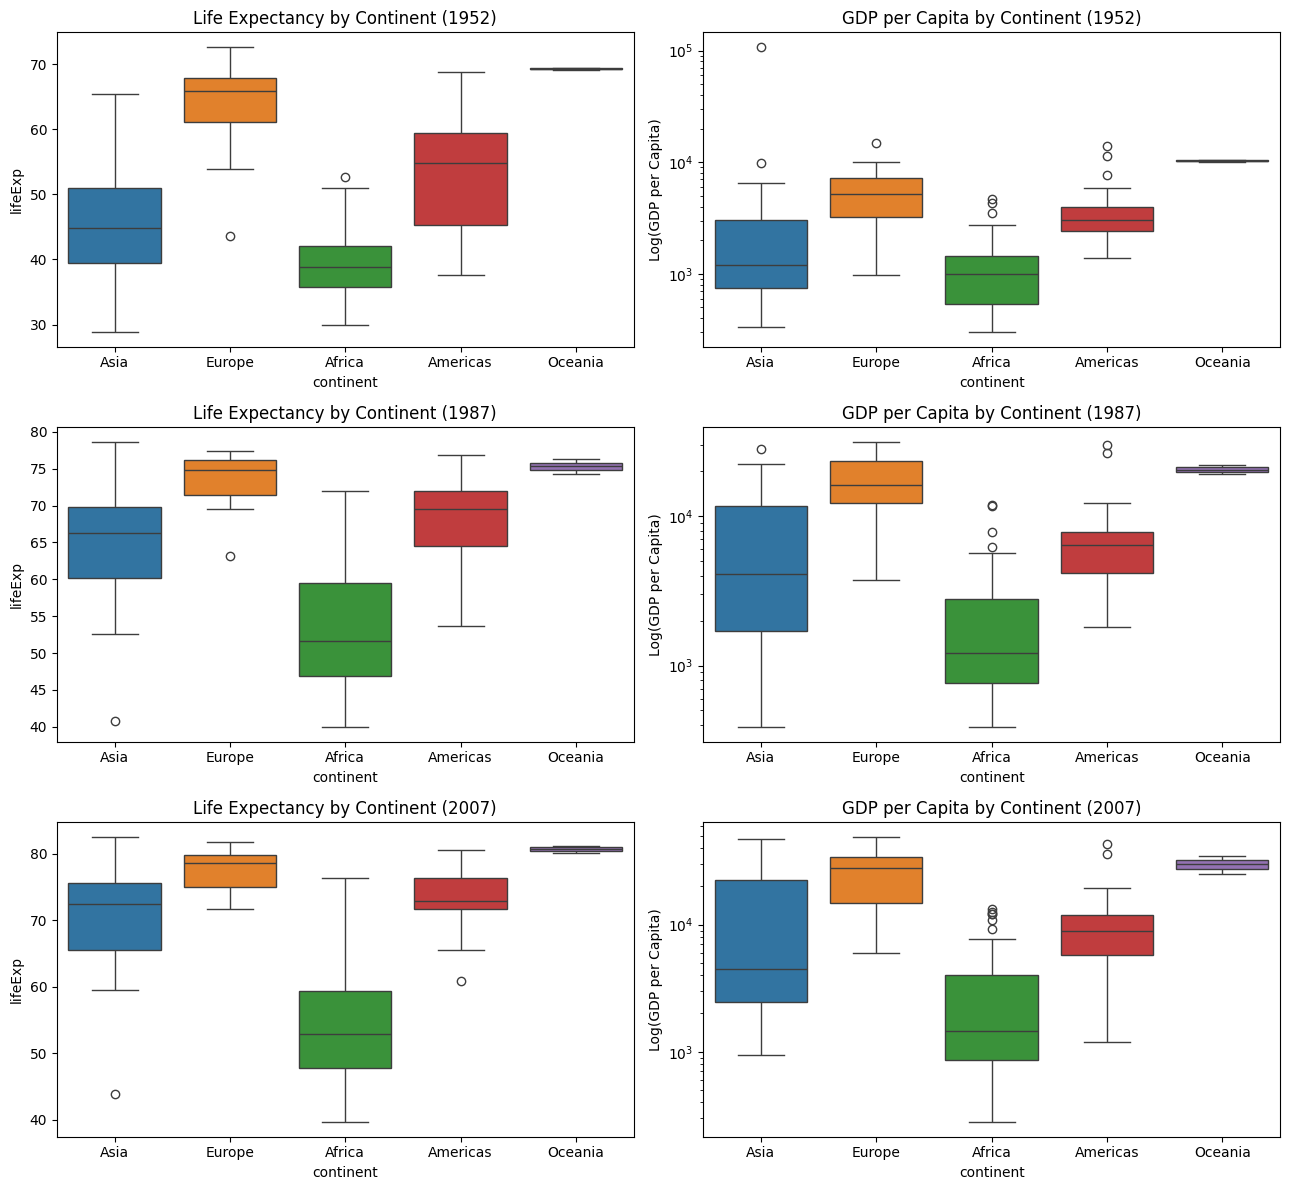

In [32]:
dfs = [year1952, year1987, year2007]
years = [1952, 1987, 2007]

fig, axes = plt.subplots(3, 2, figsize=(13, 12))

for i, (df, year) in enumerate(zip(dfs, years)):

    sns.boxplot(data=df, x="continent", y="lifeExp", hue="continent", ax=axes[i, 0])
    axes[i, 0].set_title(f"Life Expectancy by Continent ({year})")
    
    sns.boxplot(data=df, x="continent", y="gdpPercap", hue="continent", ax=axes[i, 1])
    axes[i, 1].set_yscale("log")
    axes[i, 1].set_ylabel("Log(GDP per Capita)")
    axes[i, 1].set_title(f"GDP per Capita by Continent ({year})")

plt.tight_layout()
plt.show()

**b.** We will try to confirm this using Analysis of Variance (ANOVA). 

In 2007,

- Perform one way ANOVA on `lifeExp` and `continent` (you can use `f_oneway` from `scipy.stats` module).

In [11]:
continents = df.continent.unique()
groups = [df[df['continent'] == c]['lifeExp'] for c in continents]

In [12]:
df.shape

(1704, 6)

In [35]:
from scipy.stats import f_oneway

dfs = [year1952, year1987, year2007]
years = [1952, 1987, 2007]

for df, year in zip(dfs, years):
    continents = df.continent.unique()
    groups = [df[df['continent'] == c]['lifeExp'] for c in continents]

    f_stat, p_val = f_oneway(*groups)
    print(f"F Stats: {f_stat}")
    print(f"p-value: {p_val}")
    print("="*50)

    if p_val < 0.05:
        print(f"Reject H₀: There is a significant difference in life expectancy between continents in {year}.\n")
    else:
        print(f"Fail to reject H₀: No significant difference in life expectancy between continents in {year}.\n")



F Stats: 63.59912411029363
p-value: 2.6873862888617648e-30
Reject H₀: There is a significant difference in life expectancy between continents in 1952.

F Stats: 49.71803195067778
p-value: 8.731935191139966e-26
Reject H₀: There is a significant difference in life expectancy between continents in 1987.

F Stats: 59.714003730209065
p-value: 4.217495990972493e-29
Reject H₀: There is a significant difference in life expectancy between continents in 2007.



- Do the same with `gdpPercap` and `continent`.

In [37]:
from scipy.stats import f_oneway
dfs = [year1952, year1987, year2007]
years = [1952, 1987, 2007]

for df, year in zip(dfs, years):
    continents = df.continent.unique()
    groups = [df[df['continent'] == c]['gdpPercap'] for c in continents]

    f_stat, p_val = f_oneway(*groups)
    print(f"F Stats: {f_stat}")
    print(f"p-value: {p_val}")
    print("="*50)

    if p_val < 0.05:
        print(f"Reject H0: There is a significant difference in GDP Per Capital between continents in {year}.\n")
    else:
        print(f"Fail to reject H0: No significant difference in GDP Per Capital between continents in {year}.\n")

F Stats: 1.736773547434624
p-value: 0.1453867595804702
Fail to reject H0: No significant difference in GDP Per Capital between continents in 1952.

F Stats: 30.486926767998632
p-value: 3.821575639899739e-18
Reject H0: There is a significant difference in GDP Per Capital between continents in 1987.

F Stats: 25.24196328631371
p-value: 1.1269446511148759e-15
Reject H0: There is a significant difference in GDP Per Capital between continents in 2007.



**d.** We have previously described the relationship between population and life expectancy or GDP per capita. Now, show this by defining **size** of points according to variable `pop`.

- Are these results reliable? Why?

> Your response:

- Propose ideas that might solve this problem or an alternative method.

> Your response: 

In [42]:
import plotly.express as px

fig = px.scatter(year1952, x="gdpPercap", y="lifeExp", color="continent", hover_name="country", size="pop", size_max=35)
fig.update_layout(width=800, height=500, title='Life Expectancy, GDP, Population & Continent in year 1952')
fig.update_xaxes(type="log")
fig.show()

In [43]:
fig = px.scatter(year1987, x="gdpPercap", y="lifeExp", color="continent", hover_name="country", size="pop", size_max=35)
fig.update_layout(width=800, height=500, title='Life Expectancy, GDP, Population & Continent in year 1987')
fig.update_xaxes(type="log")
fig.show()

In [44]:
fig = px.scatter(year2007, x="gdpPercap", y="lifeExp", color="continent", hover_name="country", size="pop", size_max=35)
fig.update_layout(width=800, height=500, title='Life Expectancy, GDP, Population & Continent in year 2007')
fig.update_xaxes(type="log")
fig.show()

**e.** Now, directly visualize the relation between population and life expactancy, then the relation between population and GPD per Capita. Explain the resulting graphs.

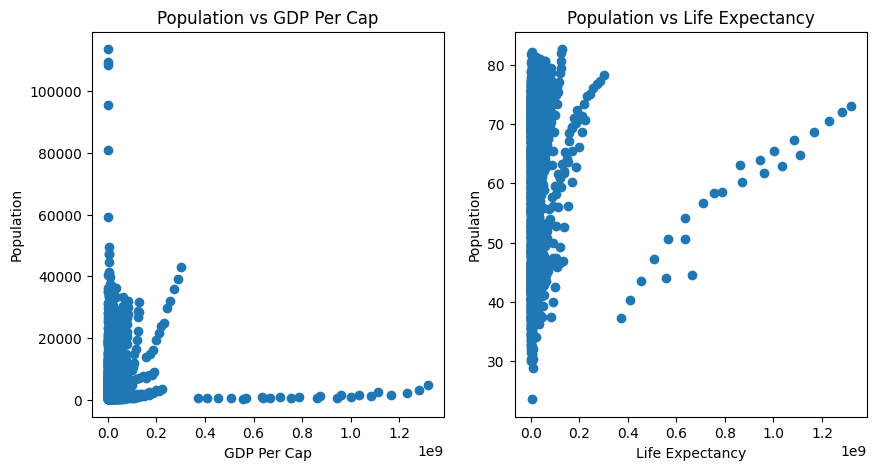

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes = axes.flatten()

axes[0].scatter(x=df['pop'], y=df['gdpPercap'], axes=axes[0])
axes[0].set_ylabel("Population")
axes[0].set_xlabel("GDP Per Cap")
axes[0].set_title("Population vs GDP Per Cap")

axes[1].scatter(x=df['pop'], y=df['lifeExp'], axes=axes[1])
axes[1].set_ylabel("Population")
axes[1].set_xlabel("Life Expectancy")
axes[1].set_title("Population vs Life Expectancy")

plt.show()

# 3. Time evolution

We have looked at the world on three frames so far (1952, 1987 and 2007). Now, we will summarize the world from 1952 to 2007 in one graph using animation tool from `plotly.express`.

- `Seaborn` was built on `Matplotlib`, making it simpler for statistical plots and integrating well with `Pandas`. It is great for quick, aesthetic and informative statistical plots.
- `Plotly` on the other hand built as highly interactive plots with features like zooming, panning, and hover information. It works well in web applications and dashboards. There are extensive customization options for aesthetics, and it supports 3D visualizations, complex plots and animations. Read more here: [https://plotly.com/python/](https://plotly.com/python/).

**a.** Using `plotly`, create one scatterplot that summarizes the world using all information: `gdpPercap`, `lifeExp`, `pop`, `continent` and set option **animation_frame="year"** which will create frame-by-frame animated scatterplot of the world from 1952 to 2007. 

In [ ]:
import plotly.io as pio
pio.renderers.default = 'notebook'
import plotly.express as px
import plotly.graph_objects as go

In [53]:
fig_anim = px.scatter(df, x="gdpPercap", y="lifeExp", animation_frame="year", animation_group="country", size="pop", color="continent", hover_name="country",
                      log_x=True, size_max=50, range_x=[100, 100000], range_y=[25,90])
fig_anim.update_layout(height=500, width=800, title="The Evolution of the World in a Single Graph")

**b.** Describe what you observed: the world from 1952 to 2007.

> Description: 

# Further readings
- Gapminder documentation: [https://www.gapminder.org/data/documentation/](https://www.gapminder.org/data/documentation/)
- A short demonstration video is available here: [Hans Rosling's 200 Countries, 200 Years, 4 Minutes - The Joy of Stats - BBC Four](https://youtu.be/jbkSRLYSojo?si=qipg08VIi999hEgo).
- Graphical tools:
    - [`matplotlib`](https://matplotlib.org/stable/index.html)
    - [`seaborn`](https://seaborn.pydata.org/)
    - [`plotly`](https://plotly.com/python/)